# Fases 1 a 3 - Corpus, limpieza y baseline SVM

El notebook usa la base reusable de `src/` y deja listo el baseline clasico sobre una muestra estratificada real.

## Trazabilidad del dataset y alcance del corpus

El corpus utilizado en este trabajo se carga desde `data/entrenamiento.csv` y se restringe a dos columnas operativas: `description` como entrada textual y `property_type` como etiqueta supervisada. La tarea consiste en clasificar avisos inmobiliarios en tres clases objetivo: `Departamento`, `Casa` y `PH`.

A nivel metodologico, este notebook trabaja sobre la version local del dataset incluida en el repositorio al momento del analisis. La particion se hace de forma reproducible con `semilla=42` y `tamanio_test=0.2`, y la muestra final puede ajustarse segun memoria disponible para mantener ejecucion estable en CPU.

Los supuestos principales son: la descripcion textual contiene suficiente senal linguistica para inferir el tipo de propiedad, las etiquetas originales del CSV son consistentes con las tres clases objetivo y el corpus representa un recorte operativo del problema, no una cobertura exhaustiva del mercado inmobiliario. En consecuencia, los resultados deben leerse como validos dentro de este dataset y de este esquema de limpieza, no como garantia de generalizacion irrestricta a otras fuentes o periodos.


In [1]:
from pathlib import Path
import sys

import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    plt = None
    sns = None

RAIZ_PROYECTO = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

import importlib
import src.property_text_pipeline
import src.evaluacion_modelos
importlib.reload(src.property_text_pipeline)
importlib.reload(src.evaluacion_modelos)

from src.artefactos_modelos import guardar_modelo_svm
from src.corpus_inmuebles import construir_tabla_distribucion_clases, preparar_corpus_para_modelado
from src.evaluacion_modelos import (
    construir_matriz_confusion_tabla,
    construir_reporte_clasificacion,
    construir_tabla_metricas,
    dibujar_matriz_confusion_profesional,
    evaluar_svm_con_validacion_cruzada,
)
from src.infraestructura_cpu import configurar_torch_cpu, relevar_hardware, sugerir_tamanio_muestra
from src.property_text_pipeline import (
    COLUMNA_OBJETIVO,
    COLUMNA_TEXTO_LIMPIO,
    TERMINOS_CLAVE,
    construir_auditoria_terminos,
    construir_ejemplos_limpieza,
    entrenar_modelo_base_svm,
    entrenar_modelo_bayes,
    entrenar_modelo_logistica,
)

In [2]:
RUTA_DATOS = RAIZ_PROYECTO / 'data' / 'entrenamiento.csv'
SEMILLA = 42
TAMANIO_TEST = 0.2

resumen = relevar_hardware()
configurar_torch_cpu()
tamanio_muestra = sugerir_tamanio_muestra(resumen.memoria_disponible_gb)
print(f'Tamanio de muestra sugerido: {tamanio_muestra}')

df_muestra, df_entrenamiento, df_prueba = preparar_corpus_para_modelado(
    ruta_datos=RUTA_DATOS,
    tamanio_muestra=tamanio_muestra,
    tamanio_test=TAMANIO_TEST,
    semilla=SEMILLA,

)

print(f'Registros en la muestra: {len(df_muestra)}')
construir_tabla_distribucion_clases(df_muestra)


Tamanio de muestra sugerido: 15000
Registros en la muestra: 15000


,clase,cantidad,porcentaje
0,Departamento,5905,39.37
1,Casa,4913,32.75
2,PH,4182,27.88


In [3]:
ratio_vacios = (df_muestra[COLUMNA_TEXTO_LIMPIO].str.len() == 0).mean()
print(f'Proporcion de texto limpio vacio: {ratio_vacios:.4f}')

ejemplos = construir_ejemplos_limpieza(df_muestra)
auditoria = construir_auditoria_terminos(df_muestra, terminos_clave=TERMINOS_CLAVE)

display(ejemplos)
display(auditoria)


Proporcion de texto limpio vacio: 0.0001


,description,texto_limpio
11865,CASA 3 DORMITORIOS - PUNTA CHACRA - ROLD&Aacut...,casa 3_dormitorios punta chacra roldan terreno...
3123,COSTAMAGNA BIENES RAICES ALQUILA TEMPORADA <br...,costamagna bienes raices alquila temporada exc...
11946,DUPLEX <br><br>SULIVAN...,duplex sulivan 1376 navarro pedriel ubicacion ...
169,IDEAL RENTA TEMPORAL AIRBNB - VIVIENDA PROPIA ...,ideal renta temporal airbnb vivienda propia pe...
8273,"Casa 3 amb: living-comedor, dos dormit (posib...",casa 3_ambientes living comedor 2 dormit posib...


,termino,coincidencias_original,coincidencias_limpio
0,expensas,3918,3918
1,balcon,4472,4472
2,entrada independiente,517,526


In [4]:
# Test de limpieza
import importlib
import src.property_text_pipeline
importlib.reload(src.property_text_pipeline)
from src.property_text_pipeline import limpiar_texto
test_text = "Semipiso premium de 78mt2, centrico, amplio y luminoso"
print(f"Original: {test_text}")
limpio = limpiar_texto(test_text)
print(f"Limpio: {limpio}")
print(f"Repr: {repr(limpio)}")

Original: Semipiso premium de 78mt2, centrico, amplio y luminoso
Limpio: semipiso premium 78_m2 centrico amplio luminoso
Repr: 'semipiso premium 78_m2 centrico amplio luminoso'


In [5]:
import re
text = "semipiso premium de 78mt2, centrico, amplio y luminoso"
print("Before fusion:", repr(text))
from src.property_text_pipeline import _fusion_semantica
after = _fusion_semantica(text)
print("After fusion:", repr(after))
aggressive = re.sub(r'[^a-záéíóúñ0-9_ ]', ' ', after)
print("After aggressive:", repr(aggressive))
final = re.sub(r'\s+', ' ', aggressive).strip()
print("Final:", repr(final))

Before fusion: 'semipiso premium de 78mt2, centrico, amplio y luminoso'
After fusion: 'semipiso premium de 78_m2, centrico, amplio y luminoso'
After aggressive: 'semipiso premium de 78_m2  centrico  amplio y luminoso'
Final: 'semipiso premium de 78_m2 centrico amplio y luminoso'


              precision    recall  f1-score   support

        Casa     0.9075    0.8598    0.8830       913
Departamento     0.9838    0.9223    0.9520      1905
          PH     0.4126    0.7912    0.5424       182

    accuracy                         0.8953      3000
   macro avg     0.7680    0.8578    0.7925      3000
weighted avg     0.9259    0.8953    0.9062      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.8953,0.768,0.8578,0.7925,0.9259,0.8953,0.9062


,metrica,media,desvio
0,accuracy,0.8627,0.0079
1,precision_macro,0.8558,0.0078
2,recall_macro,0.8526,0.0087
3,f1_macro,0.8537,0.0084
4,f1_weighted,0.8615,0.0082


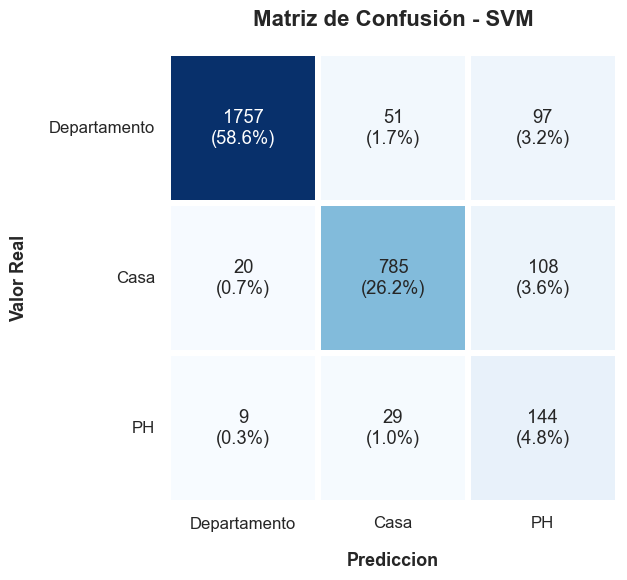

In [6]:
modelo_svm = entrenar_modelo_base_svm(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO,
)
predicciones_svm = modelo_svm.predict(df_prueba[COLUMNA_TEXTO_LIMPIO])

print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_svm))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_svm))
display(evaluar_svm_con_validacion_cruzada(df_muestra))

dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_svm,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - SVM'
)

=== Modelo Naive Bayes ===
              precision    recall  f1-score   support

        Casa     0.8390    0.7875    0.8124       913
Departamento     0.9781    0.7727    0.8633      1905
          PH     0.2132    0.7473    0.3317       182

    accuracy                         0.7757      3000
   macro avg     0.6767    0.7692    0.6692      3000
weighted avg     0.8893    0.7757    0.8156      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.7757,0.6767,0.7692,0.6692,0.8893,0.7757,0.8156


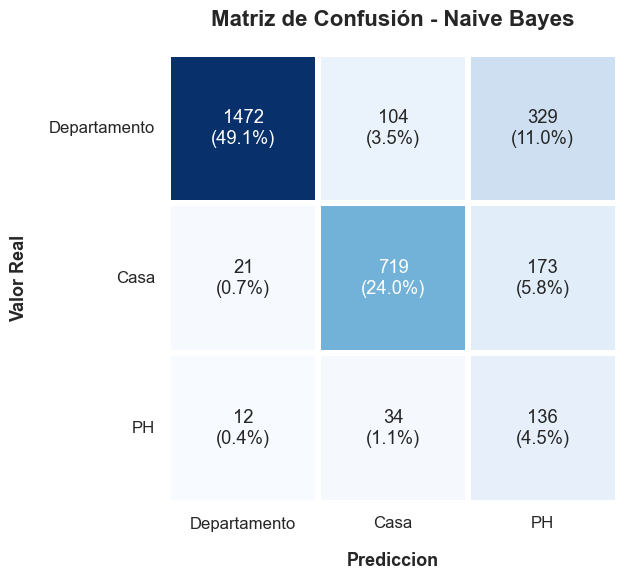

In [7]:
# Entrenamiento y evaluación del modelo Naive Bayes
modelo_bayes = entrenar_modelo_bayes(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO,
)
predicciones_bayes = modelo_bayes.predict(df_prueba[COLUMNA_TEXTO_LIMPIO])

print("=== Modelo Naive Bayes ===")
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes))

dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_bayes,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Naive Bayes'
)

=== Modelo Regresión Logística ===
              precision    recall  f1-score   support

        Casa     0.9133    0.8773    0.8950       913
Departamento     0.9860    0.9260    0.9551      1905
          PH     0.4401    0.8077    0.5698       182

    accuracy                         0.9040      3000
   macro avg     0.7798    0.8703    0.8066      3000
weighted avg     0.9308    0.9040    0.9134      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.904,0.7798,0.8703,0.8066,0.9308,0.904,0.9134


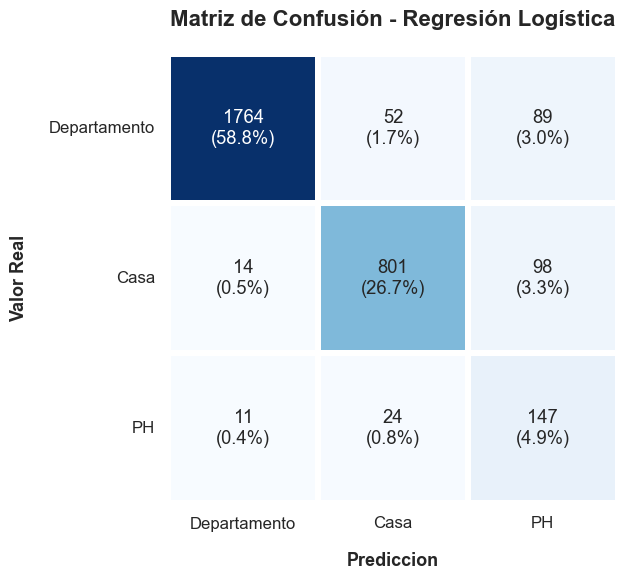

In [8]:
# Entrenamiento y evaluación del modelo de Regresión Logística
modelo_logistica = entrenar_modelo_logistica(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO,
)
predicciones_logistica = modelo_logistica.predict(df_prueba[COLUMNA_TEXTO_LIMPIO])

print("=== Modelo Regresión Logística ===")
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica))

dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_logistica,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Regresión Logística'
)

In [9]:
ruta_modelo = guardar_modelo_svm(modelo_svm)
print(f'Modelo SVM guardado en: {ruta_modelo}')


Modelo SVM guardado en: /home/juan/Documentos/Ciencia de Datos/08 _Seminario de procesamiento de lenguaje natural/TFI/nlp_trabajo_final/artifacts/modelo_svm.joblib


## Referencia operativa a la mini-API local

El baseline SVM entrenado en este notebook se persiste como artefacto reusable y alimenta la mini-API local definida en `src/api_local.py`. El flujo esperado es: primero ejecutar este notebook para generar `artifacts/modelo_svm.joblib`, luego levantar la API con FastAPI y consultar el endpoint de prediccion.

Ejemplo minimo de uso local:

```bash
uvicorn src.api_local:app --reload
```

Chequeo de salud:

```bash
curl http://127.0.0.1:8000/salud
```

Prediccion de prueba:

```bash
curl -X POST http://127.0.0.1:8000/predecir \
  -H "Content-Type: application/json" \
  -d '{"descripcion":"PH interno de 3 ambientes con entrada independiente"}'
```

La respuesta devuelve la clase predicha, el texto limpio usado por el pipeline y la ruta del artefacto cargado. Con esto, la implementacion minima exigida por la consigna queda conectada con el modelo clasico efectivamente entrenado en el repositorio.


## Análisis de Data Leakage
Calculamos la cantidad de registros que contienen palabras clave que delatan su clase directamente en la descripción original.


In [10]:
import pandas as pd
import re

keywords = {
    'Casa': r'\bcasa\b',
    'Departamento': r'\b(?:departamento|depto|dpto)\b',
    'PH': r'\b(?:ph|horizontal)\b'
}

resultados = []

for clase, patron in keywords.items():
    df_clase = df_muestra[df_muestra['property_type'] == clase]
    total = len(df_clase)

    con_palabra = df_clase['description'].str.lower().str.contains(patron, regex=True, na=False).sum()
    porcentaje = (con_palabra / total * 100) if total > 0 else 0

    resultados.append({
        'Clase': clase,
        'Total Registros': total,
        'Contienen Palabra Clave': con_palabra,
        'Porcentaje (%)': round(porcentaje, 2)
    })

df_res = pd.DataFrame(resultados)
display(df_res)


,Clase,Total Registros,Contienen Palabra Clave,Porcentaje (%)
0,Casa,4913,3410,69.41
1,Departamento,5905,3641,61.66
2,PH,4182,2333,55.79


## Modelos con Datos Censurados (Sin Data Leakage)
Entrenamos los mismos modelos pero usando la columna sin las palabras clave que delatan la clase.


=== Modelo SVM Censurado ===
              precision    recall  f1-score   support

        Casa     0.8706    0.7886    0.8276       913
Departamento     0.9705    0.8646    0.9145      1905
          PH     0.2899    0.7582    0.4195       182

    accuracy                         0.8350      3000
   macro avg     0.7104    0.8038    0.7205      3000
weighted avg     0.8988    0.8350    0.8580      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.835,0.7104,0.8038,0.7205,0.8988,0.835,0.858


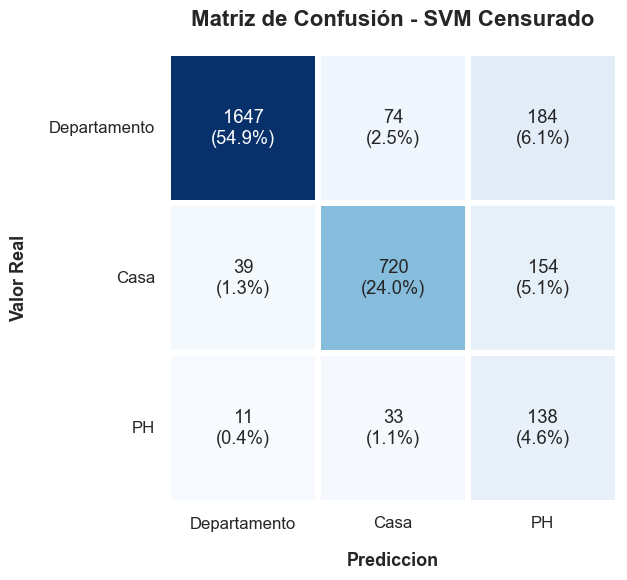

=== Modelo Naive Bayes Censurado ===
              precision    recall  f1-score   support

        Casa     0.8106    0.7733    0.7915       913
Departamento     0.9699    0.7438    0.8419      1905
          PH     0.1916    0.7033    0.3012       182

    accuracy                         0.7503      3000
   macro avg     0.6574    0.7401    0.6449      3000
weighted avg     0.8742    0.7503    0.7938      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.7503,0.6574,0.7401,0.6449,0.8742,0.7503,0.7938


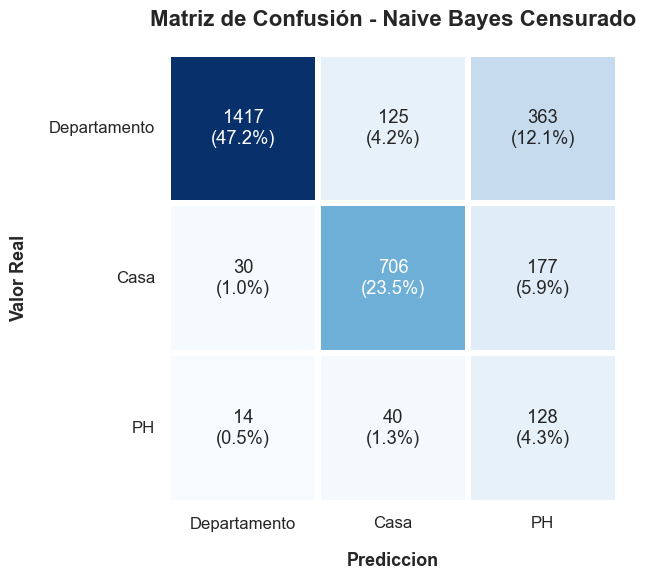

=== Modelo Regresión Logística Censurada ===
              precision    recall  f1-score   support

        Casa     0.8812    0.8039    0.8408       913
Departamento     0.9742    0.8709    0.9196      1905
          PH     0.3103    0.7912    0.4458       182

    accuracy                         0.8457      3000
   macro avg     0.7219    0.8220    0.7354      3000
weighted avg     0.9056    0.8457    0.8669      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.8457,0.7219,0.822,0.7354,0.9056,0.8457,0.8669


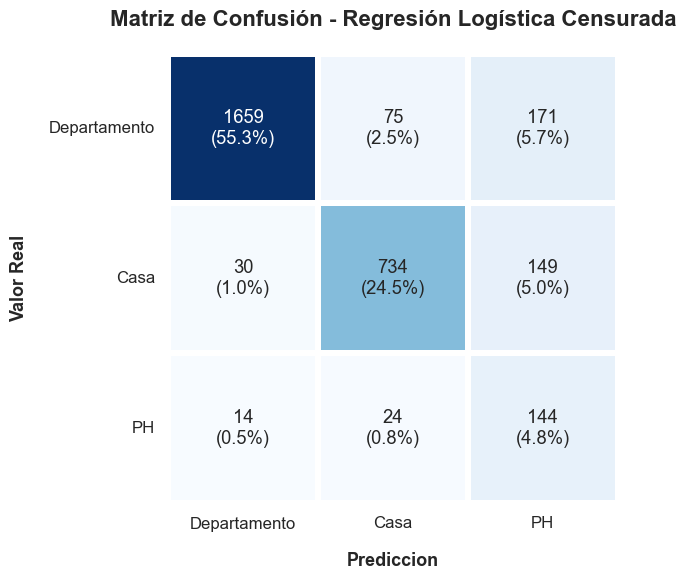

In [11]:
from src.property_text_pipeline import COLUMNA_TEXTO_LIMPIO_CENSURADO

# SVM Censurado
print("=== Modelo SVM Censurado ===")
modelo_svm_censurado = entrenar_modelo_base_svm(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO_CENSURADO,
)
predicciones_svm_censurado = modelo_svm_censurado.predict(df_prueba[COLUMNA_TEXTO_LIMPIO_CENSURADO])
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_svm_censurado))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_svm_censurado))
dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_svm_censurado,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - SVM Censurado'
)

# Naive Bayes Censurado
print("=== Modelo Naive Bayes Censurado ===")
modelo_bayes_censurado = entrenar_modelo_bayes(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO_CENSURADO,
)
predicciones_bayes_censurado = modelo_bayes_censurado.predict(df_prueba[COLUMNA_TEXTO_LIMPIO_CENSURADO])
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes_censurado))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes_censurado))
dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_bayes_censurado,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Naive Bayes Censurado'
)

# Regresion Logistica Censurada
print("=== Modelo Regresión Logística Censurada ===")
modelo_logistica_censurado = entrenar_modelo_logistica(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO_CENSURADO,
)
predicciones_logistica_censurado = modelo_logistica_censurado.predict(df_prueba[COLUMNA_TEXTO_LIMPIO_CENSURADO])
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica_censurado))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica_censurado))
dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_logistica_censurado,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Regresión Logística Censurada'
)

## Etica, sesgos y limites de interpretacion

Este corpus presenta varios riesgos metodologicos que deben declararse. Primero, existe ambiguedad semantica genuina entre clases, especialmente en avisos donde `PH`, `departamento tipo casa` o descripciones hibridas comparten vocabulario. Segundo, el desbalance de clases y la presencia de terminos altamente informativos pueden inflar el desempeno si no se controla el data leakage. Por eso se incluye un escenario censurado que remueve palabras clave evidentes de clase.

Tambien hay limites de generalizacion: el modelo aprende sobre un recorte puntual del mercado y sobre una normalizacion textual especifica. No debe interpretarse como clasificador universal de lenguaje inmobiliario ni como criterio apto para decisiones de negocio sin recalibracion sobre nuevas fuentes. En terminos de uso responsable, los resultados deben leerse como evidencia tecnica comparativa dentro del trabajo y no como sustituto de validacion humana o de control de calidad del dato de origen.
